# LeetCode #103: Binary Tree Zigzag Level Order Traversal

https://leetcode.com/problems/binary-tree-zigzag-level-order-traversal/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| BFS + Reverse Alternate Levels | O(n) | O(n) | Normal BFS, reverse odd-indexed levels |
| **BFS + Direction Flag ★** | **O(n)** | **O(n)** | Toggle leftToRight; insert at front or back of deque |

---

## Understanding the Methods

### Brute Force (BFS + Reverse)
Run standard BFS collecting each level normally. After collecting all levels, reverse the odd-indexed ones. Simple but requires post-processing.

### BFS + Direction Flag (Optimal ★)
Use a queue for BFS. Maintain a `leftToRight` boolean. For each level, use a LinkedList (deque): if leftToRight, AddLast; else AddFirst. Toggle flag after each level. O(n) with no extra reversal passes.

## Constraints
- Number of nodes: [0, 2000]
- Node values: [-100, 100]

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> ZigzagLevelOrder(TreeNode root) {
        var result = new List<IList<int>>();
        if (root == null) return result;
        var queue = new Queue<TreeNode>();
        queue.Enqueue(root);
        bool leftToRight = true;
        while (queue.Count > 0) {
            int size = queue.Count;
            var level = new LinkedList<int>();
            for (int i = 0; i < size; i++) {
                var node = queue.Dequeue();
                if (leftToRight) level.AddLast(node.val);
                else             level.AddFirst(node.val);
                if (node.left  != null) queue.Enqueue(node.left);
                if (node.right != null) queue.Enqueue(node.right);
            }
            result.Add(new List<int>(level));
            leftToRight = !leftToRight;
        }
        return result;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def zigzagLevelOrder(self, root) -> list[list[int]]:
        if not root:
            return []
        result, queue, left_to_right = [], deque([root]), True
        while queue:
            level = deque()
            for _ in range(len(queue)):
                node = queue.popleft()
                if left_to_right: level.append(node.val)
                else:             level.appendleft(node.val)
                if node.left:  queue.append(node.left)
                if node.right: queue.append(node.right)
            result.append(list(level))
            left_to_right = not left_to_right
        return result

### Go

In [ ]:
func zigzagLevelOrder(root *TreeNode) [][]int {
    if root == nil { return nil }
    result := [][]int{}
    queue  := []*TreeNode{root}
    leftToRight := true
    for len(queue) > 0 {
        size  := len(queue)
        level := make([]int, size)
        for i := 0; i < size; i++ {
            node  := queue[0]; queue = queue[1:]
            if leftToRight { level[i] = node.Val } else { level[size-1-i] = node.Val }
            if node.Left  != nil { queue = append(queue, node.Left) }
            if node.Right != nil { queue = append(queue, node.Right) }
        }
        result = append(result, level)
        leftToRight = !leftToRight
    }
    return result
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::VecDeque;

impl Solution {
    pub fn zigzag_level_order(root: Option<Rc<RefCell<TreeNode>>>) -> Vec<Vec<i32>> {
        let mut result = vec![];
        let Some(r) = root else { return result; };
        let mut queue = VecDeque::from([r]);
        let mut left_to_right = true;
        while !queue.is_empty() {
            let size = queue.len();
            let mut level = vec![0i32; size];
            for i in 0..size {
                let node = queue.pop_front().unwrap();
                let val  = node.borrow().val;
                if left_to_right { level[i] = val; } else { level[size-1-i] = val; }
                if let Some(l) = node.borrow().left.clone()  { queue.push_back(l); }
                if let Some(r) = node.borrow().right.clone() { queue.push_back(r); }
            }
            result.push(level);
            left_to_right = !left_to_right;
        }
        result
    }
}

## Example Scenarios

### 1. Common Case — Standard 3-Level Tree
**Input:** `root = [3, 9, 20, null, null, 15, 7]`

L0 (→): collect [3]. L1 (←): dequeue 9 then 20, but insert at front → [20, 9]. L2 (→): collect [15, 7] normally. Direction flag toggles after each level.

WHY: Validates basic zigzag alternation. L1 reversal with AddFirst/appendleft must produce [20, 9] not [9, 20].

$O(n) = O(5)$. Deque insertions: $O(1)$ each.

**Output:** `[[3], [20, 9], [15, 7]]`

---

### 2. Slightly Complex — 4-Level Complete Tree (15 nodes)
**Input:** `root = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]`

Four levels: L0→[1], L1←[3,2], L2→[4,5,6,7], L3←[15,14,13,12,11,10,9,8]. The 8-node last level is the widest reversal — 8 AddFirst operations.

WHY: Tests zigzag with 4 levels including a wide reversal of 8 nodes. Confirms the deque insertion approach scales without $O(n)$ reversal cost per level.

**Output:** `[[1], [3, 2], [4, 5, 6, 7], [15, 14, ..., 8]]`

---

### 3. Edge Case: Time Factor — Left-Skewed Chain of 2000 Nodes
**Input:** `root = 1 ← 2 ← 3 ← ... ← 2000` (each node has only a left child)

2000 levels, each with 1 node. Direction toggles but single-element levels are unaffected by reversal. BFS runs 2000 iterations — maximum possible.

WHY: Worst-case iteration count at $n = 2000$. Single-element levels make the direction flag irrelevant, testing that the toggle logic works when reversal is a no-op.

$O(n) = O(2000)$. Direction toggles 2000 times.

**Output:** `[[1], [2], ..., [2000]]`

---

### 4. Edge Case: Space Factor — Perfect Tree, 1023 Nodes
**Input:** `root = perfect binary tree, 1023 nodes`

Queue peaks at 512 nodes (level 9). The zigzag deque for that level also holds 512 elements. The RTL level requires 512 AddFirst operations. If using a list instead of deque, this becomes $O(n^2)$ per level.

WHY: Worst space + hidden performance trap. Using `list.insert(0, val)` instead of deque.appendleft is $O(k)$ per insert, making the whole level $O(k^2)$ where $k = 512$.

**Output:** 10 levels with alternating direction, widest = 512 nodes reversed

---

### 5. Almost-Impossible but Plausible — Negative Values & Symmetric Decoy
**Input:** `root = [-100, 99, -99, 98, -98, 97, -97]`

Values near constraint boundaries $[-100, 100]$ in a near-symmetric pattern. L0→[-100]. L1←[-99, 99] (reversed from BFS order [99, -99]). L2→[98, -98, 97, -97].

WHY: Near-palindromic levels create a decoy. Without zigzag L1 = [99, -99]; with zigzag it's [-99, 99]. Interviewers watch whether candidates confuse BFS order with zigzag order.

**Output:** `[[-100], [-99, 99], [98, -98, 97, -97]]`

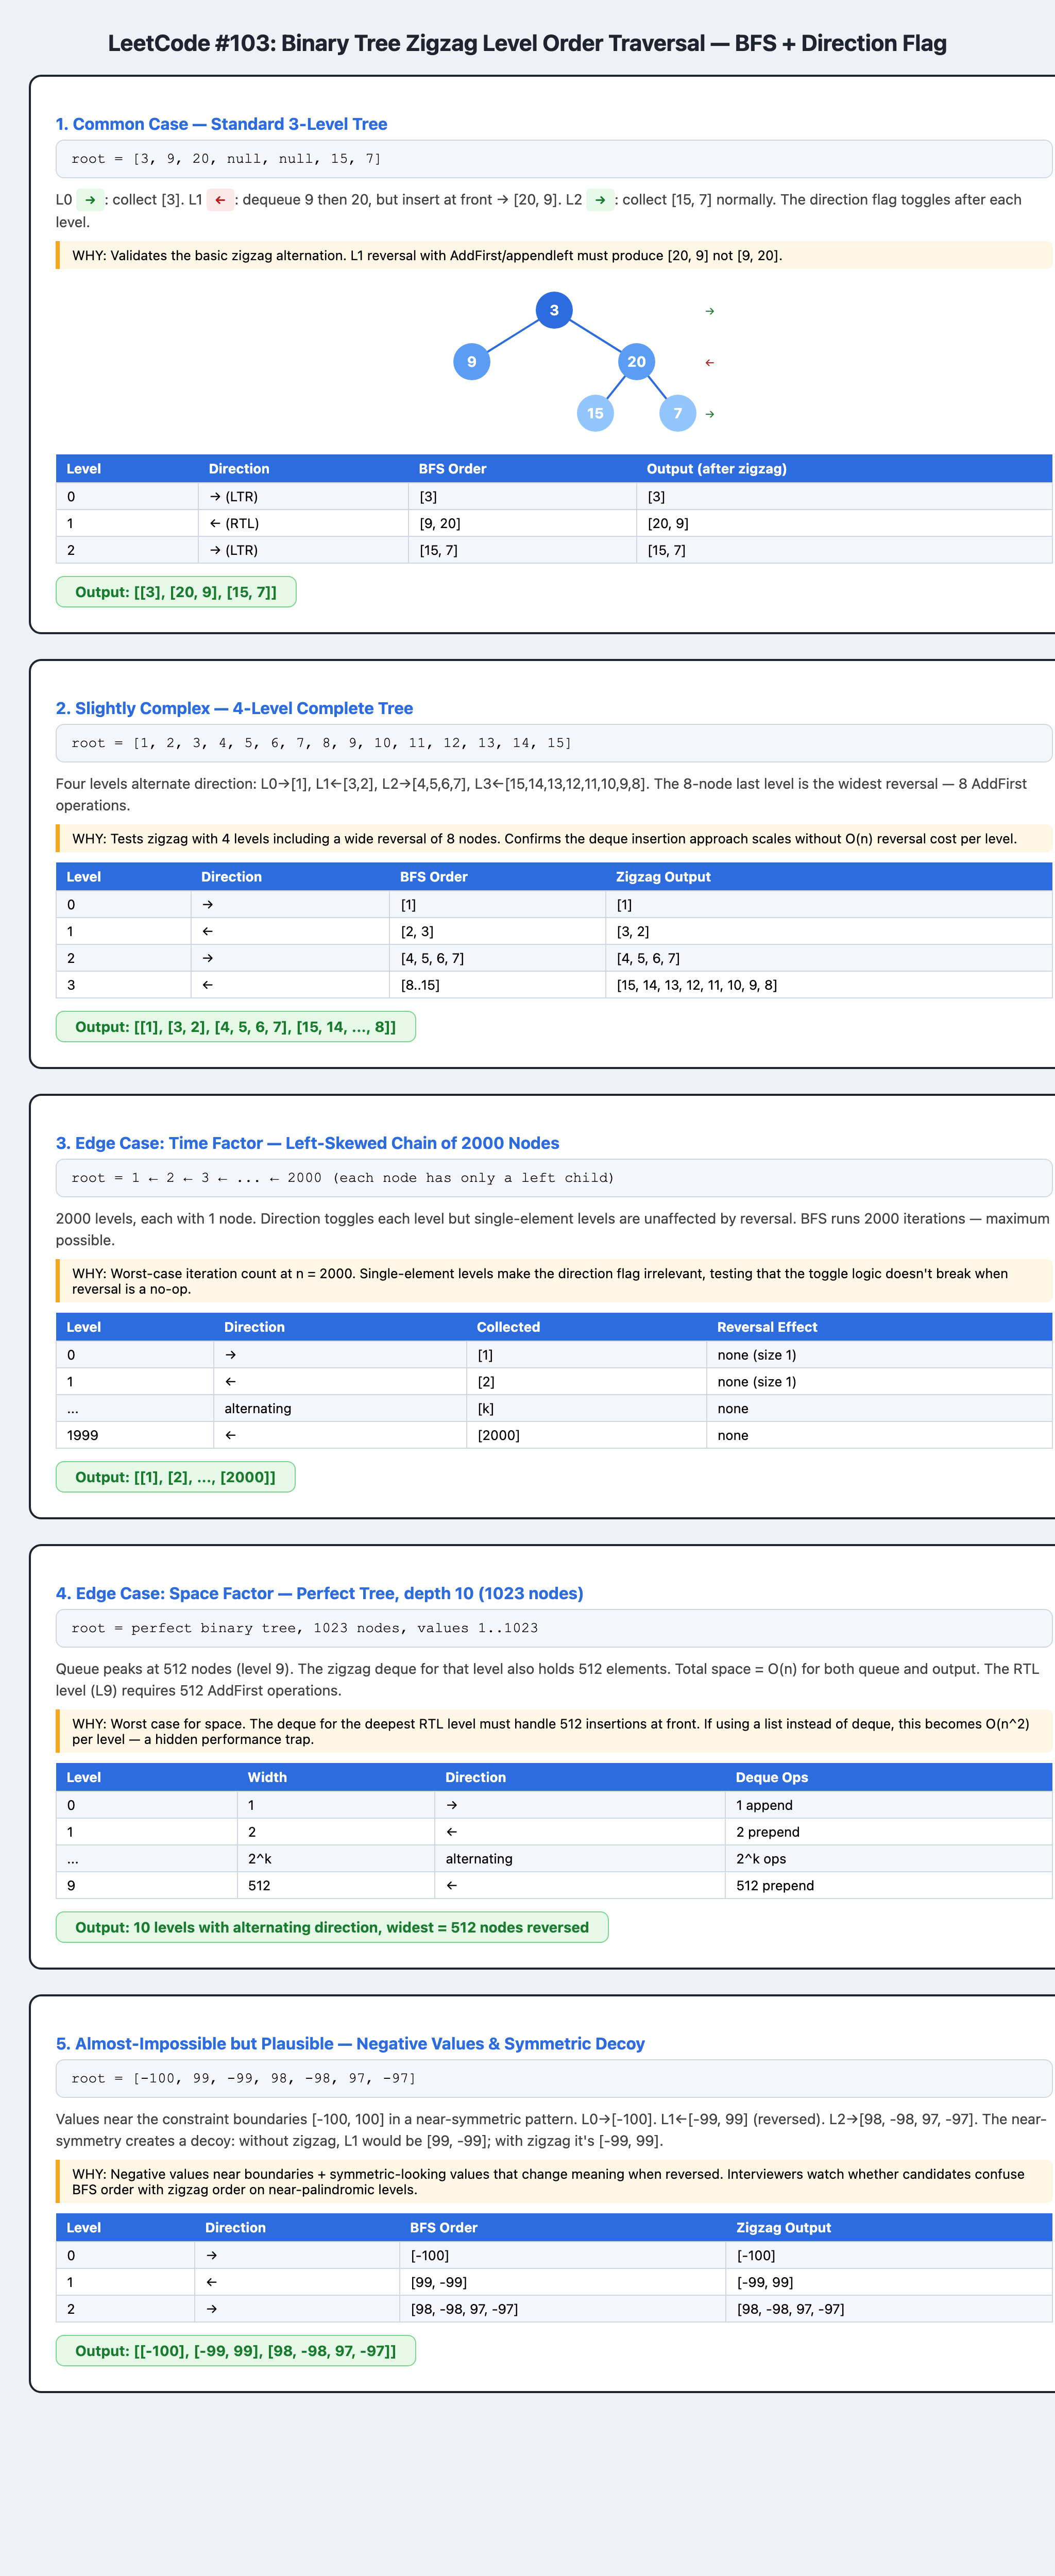